1. Importing the Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

2. Data Cleaning

In [ ]:
# Loading the dataset
df = pd.read_csv('creditcard.csv')

# Checking for missing values
print(df.isnull().sum())

# Basic info about the data
print(df.info())

# Dropping duplicates if any
df = df.drop_duplicates()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23858 entries, 0 to 23857
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    23858 non-null  int64  
 1   V1      23858 non-null  float64
 2   V2      23858 non-null  float64
 3   V3      23858 non-null  float64
 4   V4      23858 non-null  float64
 5   V5      23858 non-null  float64
 6   V6      23858 non-null  float64
 7   V7      23858 non-null  float64
 8   V8      23858 non-null  float64
 9   V9      23858 non-null  float64
 10  V10     23858 non-null  float64
 11  V11     23858 non-nu

3. Data Visualization

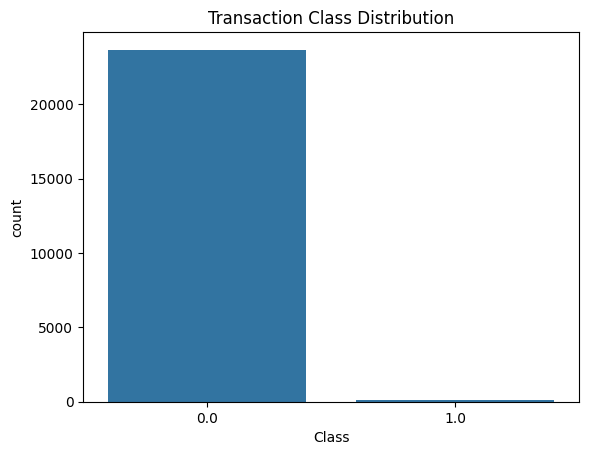

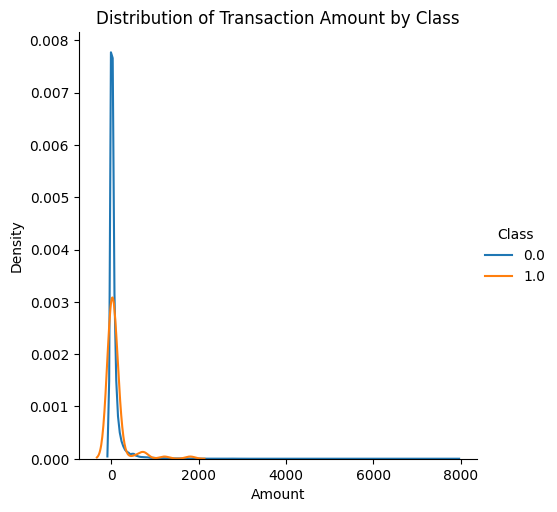

In [ ]:
# Class distribution (0 = Genuine, 1 = Fraud)
sns.countplot(x='Class', data=df)
plt.title('Transaction Class Distribution')
plt.show()

# Amount vs Class comparison
sns.FacetGrid(df, hue="Class", height=5).map(sns.kdeplot, "Amount").add_legend()
plt.title('Distribution of Transaction Amount by Class')
plt.show()

4. Splitting the Data into Features and Targets

In [ ]:
# Separating the data for analysis
# 'Class' column is our target, others are features
X = df.drop(columns='Class', axis=1)
Y = df['Class']

print(X.shape, Y.shape)

(23770, 30) (23770,)


5. Splitting the Data into Training and Test Data

In [ ]:
# Drop rows where Y is NaN to ensure no missing values before splitting
df_cleaned = df.dropna(subset=['Class'])
X = df_cleaned.drop(columns='Class', axis=1)
Y = df_cleaned['Class']

# 80% Training data, 20% Testing data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (19015, 30)
Testing data shape: (4754, 30)


6. Model Training

In [ ]:
model = LogisticRegression(max_iter=1000)

# Training the Logistic Regression Model with Training Data
model.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

7. Model Evaluation

In [ ]:
# Accuracy on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print(f'Accuracy on Training data: {training_data_accuracy * 100:.2f}%')

# Accuracy on test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print(f'Accuracy on Test data: {test_data_accuracy * 100:.2f}%')

# Detailed Evaluation
print("\nClassification Report:")
print(classification_report(Y_test, X_test_prediction))

Accuracy on Training data: 99.89%
Accuracy on Test data: 99.79%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      4736
         1.0       0.90      0.50      0.64        18

    accuracy                           1.00      4754
   macro avg       0.95      0.75      0.82      4754
weighted avg       1.00      1.00      1.00      4754



8. Making a Predictive System

In [ ]:
# Let's take a row of data at random.  (Sample input)
input_data = (0, -1.359807134, -0.072781173, 2.536346738, 1.378155224, -0.33832077, 0.462387778, 0.239598554, 0.098697918, 0.36378697, 0.090794172, -0.551599533, -0.617800856, -0.991389848, -0.311169354, 1.468176972, -0.470400525, 0.207971242, 0.02579058, 0.40399296, 0.251412098, -0.018306778, 0.2778381, -0.11047391, 0.066928075, 0.128539358, -0.189114844, 0.133558377, -0.021053053, 149.62)

# Convert it into a NumPy array and then reshape it.
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

# Prediction
prediction = model.predict(input_data_reshaped)

if (prediction[0] == 0):
  print('✅ This is a Normal Transaction')
else:
  print('🚨 ALERT: This is a Fraudulent Transaction')

✅ This is a Normal Transaction


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


9. Training with Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Model initialization
# n_estimators=100 means 100 decision trees create pannum
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the model
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

10. Improved Model Evaluation

In [ ]:
# Predictions
rf_test_prediction = rf_model.predict(X_test)

# Accuracy check
rf_accuracy = accuracy_score(rf_test_prediction, Y_test)
print(f'Random Forest Accuracy: {rf_accuracy * 100:.2f}%')

# Precision and Recall (Intha project-ku idhu dhan King!)
print("\nClassification Report (Random Forest):")
print(classification_report(Y_test, rf_test_prediction))

Random Forest Accuracy: 99.94%

Classification Report (Random Forest):
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      4736
         1.0       0.94      0.89      0.91        18

    accuracy                           1.00      4754
   macro avg       0.97      0.94      0.96      4754
weighted avg       1.00      1.00      1.00      4754



11. Feature Importance

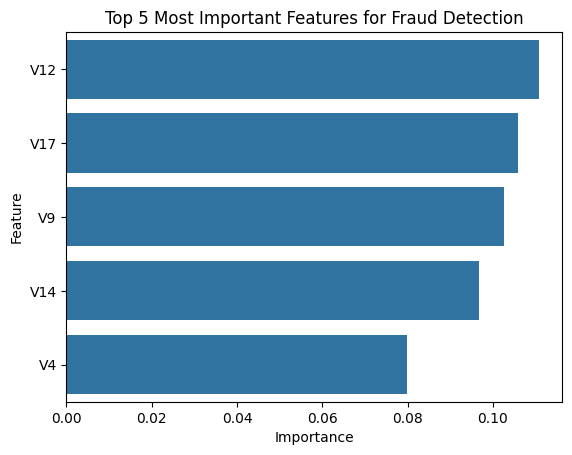

In [ ]:
# Finding which features are most important
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Top 5 features visualization
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(5))
plt.title('Top 5 Most Important Features for Fraud Detection')
plt.show()

12. Saving the Model

In [ ]:
import pickle

# We are saving the model as a file.
filename = 'trained_model.sav'
pickle.dump(rf_model, open(filename, 'wb'))

print("Model saved successfully!")

Model saved successfully!
